# Manejo de librerías e instalaciones

In [49]:
!pip install experta
%pip install scipy
%pip install networkx
%pip install scikit-fuzzy
%pip install matplotlib



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports y parches de compatibilidad

In [50]:
import collections.abc
if not hasattr(collections, 'Mapping'):
    collections.Mapping = collections.abc.Mapping

# Sistema experto
from experta import KnowledgeEngine, Rule, AND, OR, Fact
from experta import *
from experta.strategies import DepthStrategy

# Lógica difusa
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl


# Sistema Experto

## Definición de Hechos (Facts)

Cada clase hereda de `Fact` y representa una entidad del dominio de conocimiento.

**Preguntar de monitoría:** Aplicación de *specificity* en nuestro sistema experto

In [51]:
class cliente(Fact): #clase cliente
    pass

class tipo_producto(Fact): #tipo de productos que busca el cliente
    """
    tipo categorico
    parametros: Maquillaje, Prenda superior, Prenda inferior
    """
    pass

class PerfilEconomico(Fact): #perfil economico del cliente
    """
    tipo: categorico
    parametros: bajo, ligeramente_bajo, medio, alto, muy_alto, 
    """
    pass

class Dermatologico(Fact): #tipo de piel del cliente
    """
    tipo: categorico
    parametros: normal, seca, grasa, mixta, sensible
    """
    pass

class alergias(Fact): #alergias del cliente
    """
    tipo: categorico
    parametros: Fragancias, Colorantes, Níquel, Aceites, extractos vegetales, Null
    """
    pass

class marcas_preferida(Fact): #marcas preferidas del cliente
    pass

class marcas_evitada(Fact): #marcas que el cliente prefiere evitar
    pass

class Maquillaje(Fact): #tipo de maquillaje
    """
    tipo: Categorico
    parametros: Base , Corrector, Polvo, Sombra de ojos, Delineador, Labial
    """
    pass

class marcas_maquillaje(Fact): #marcas de maquillaje disponibles
    """
    tipo: categorico
    parametros: Loreal, Maybelline, MAC, Clinique, Fenty Beauty, NARS, NYX, Revlon
    """
    pass

class ingredientes_Maquillaje(Fact): #ingredientes en los maquillajes
    """
    tipo: categorico
    parametros: Fragancias, Colorantes, Níquel, Aceites, extractos vegetales,
    """
    pass

class Prenda_Superior(Fact): #marcas de prenda superior
    """
    tipo: categorica
    parametros: Zara, H&M, Uniqlo, Tommy Hilfiger, Ralph Lauren, Pull&Bear, Bershka, Calvin Klein
    """
    pass

class tipos_prendas_superiores(Fact): #tipos de prendas superiores
    """
    tipo: categorica
    parametros: Camisas, Blusas, Chaquetas, Suéteres, Abrigos, Camisetas, Sudaderas, Chalecos
    """
    pass

class Prenda_Inferior(Fact): #marcas de prenda inferior
    """
    tipo: categorica
    parametros:levis, Diesel, ,Wrangler, American Eagle, Guess, Stradivarius, Massimo Dutti, Dockers
    """
    pass


class tipos_prendas_inferiores(Fact): #tipos de prendas inferiores
    """
    tipo: categorica
    parametros: Jeans, Faldas, Shorts, Leggings, deportivos
    """
    pass

class Materiales_prendas(Fact): #materiales de las prendas superiores e inferiores
    """
    tipo: categorica
    parametros: Algodón, Poliéster, Lana, Seda, Denim, Lino
    """
    pass

class EjecutadoFact(Fact): #clase para verificar si una regla ya se ejecuto previamente
    """
    tipo: categorico
    parametros: regla
    """
    pass

## Motor de Inferencia

### Tabla de prioridades (`salience`)

| Salience | Descripción |
|---|---|
| 180 | Mostrar perfil del cliente |
| 140 | Marcas de maquillaje disponibles |
| 139 | Marca preferida fuera de rango (maquillaje) |
| 138 | Filtrar por alergias (maquillaje) |
| 137 | Marcas por preferencias (maquillaje) |
| 135 | Recomendaciones por tipo de piel (maquillaje) |
| 130 | Marcas de prendas superiores disponibles |
| 129 | Marca preferida fuera de rango (superior) |
| 128 | Filtrar por alergias (superior) |
| 127 | Marcas por preferencias (superior) |
| 126 | Recomendaciones piel sensible (superior) |
| 120 | Marcas de prendas inferiores disponibles |
| 119 | Marca preferida fuera de rango (inferior) |
| 118 | Filtrar por alergias (inferior) |
| 117 | Marcas por preferencias (inferior) |
| 116 | Recomendaciones piel sensible (inferior) |

In [52]:



# SISTEMA DE RECOMENDACIÓN DE MAQUILLAJE Y ROPA BASADO EN PERFIL DEL CLIENTE
class SistemaRecomendacion(KnowledgeEngine):

    #=========================================
    #REGLA PARA MOSTRAR PERFIL DEL CLIENTE
    #=========================================
    @Rule(cliente(marca_preferida=MATCH.marca_pref,
                  tipo_producto=MATCH.tipo_prod,
                  perfil_economico=MATCH.perfil_econ,
                  perfil_dermatologico=MATCH.perfil_derm,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit),salience=180) #salience para que esta regla se ejecute antes que las demás y muestre el perfil del cliente antes de mostrar las recomendaciones
    def validar_perfil_cliente(self, marca_pref, tipo_prod, perfil_econ,
                                perfil_derm, alergias, marcas_evit):
        print("\n" + "=" * 80)
        print("PERFIL DEL CLIENTE")
        print("=" * 80)
        print(f"Marca preferida: {marca_pref}")
        print(f"Tipo de producto: {tipo_prod}")
        print(f"Perfil económico: {perfil_econ}")
        print(f"Tipo de piel: {perfil_derm}")
        print(f"Alergias: {list(alergias) if alergias else 'Ninguna'}")
        print(f"Marcas evitadas: {list(marcas_evit) if marcas_evit else 'Ninguna'}")
        print("=" * 80)



    #=========================================
    #REGLAS PARA MOSTRAR MARCAS DISPONIBLES EN BASE AL PERFIL ECONÓMICO DEL CLIENTE
    #=========================================

    #=========================
    #MAQUILLAJES
    #==========================

    #regla para mostrar las marcas de maquillaje disponibles dado el perfil económico del cliente
    @Rule(cliente(tipo_producto='Maquillaje', marca_preferida=MATCH.marca_pref,
            perfil_economico=MATCH.perfil_econ),
            NOT(EjecutadoFact(regla='mostrar_marcas_maquillaje')),  # evita re-ejecución
    salience=140)
    def mostrar_marcas_maquillaje_disponibles(self, marca_pref, perfil_econ):
        # control de ejecucion no loop
        self.declare(EjecutadoFact(regla='mostrar_marcas_maquillaje'))
        #set() para evitar marcas repetidas
        marcas = set()
        marca_preferida_disponible = False

        for x, fact in self.facts.items():
            # Recorre los hechos para encontrar los perfiles económicos de las marcas
            if isinstance(fact, PerfilEconomico):
                marca = fact.get('marca')
                perfil = fact.get('perfil_economico')
                # Verifica si la marca tiene productos de maquillaje disponibles
                es_maquillaje = False
                for y, fact2 in self.facts.items():
                    if isinstance(fact2, Maquillaje) and fact2.get('marca') == marca:
                        es_maquillaje = True
                        break
                # Si la marca tiene maquillaje y su perfil económico coincide con el del cliente, se agrega a la lista de marcas disponibles
                if es_maquillaje and perfil == perfil_econ:
                    marcas.add(marca)
                    if marca == marca_pref:
                        marca_preferida_disponible = True

        # Imprime las marcas de maquillaje disponibles dado los parametros del cliente
        print(f"\nMARCAS DE MAQUILLAJE DISPONIBLES (Perfil: {perfil_econ}):")
        for marca in sorted(marcas):
            if marca == marca_pref:
                print(f"* {marca} -> MARCA PREFERIDA")
            else:
                print(f"* {marca}")


    #regla para mostrar un mensaje si la marca preferida del cliente no está disponible dentro de su rango económico
    @Rule(cliente(tipo_producto='Maquillaje',
                  perfil_economico=MATCH.perfil_econ,
                  marca_preferida=MATCH.marca_pref), salience=139)#salience para que esta regla se ejecute después de mostrar las marcas disponibles y así mostrar el mensaje si la marca preferida no está disponible dentro del rango económico del cliente
    def verificar_marca_maquillaje_fuera_rango(self, perfil_econ, marca_pref):

        orden = {'bajo': 1, 'ligeramente_bajo': 2, 'medio': 3, 'alto': 4, 'muy_alto': 5}
        perfil_marca = None

        for fact in self.facts.values():
            if isinstance(fact, PerfilEconomico) and fact.get('marca') == marca_pref:
                perfil_marca = fact.get('perfil_economico')
                break

        if perfil_marca and orden[perfil_marca] > orden[perfil_econ]:
            print(f"\nTu marca preferida de maquillaje '{marca_pref}' "
                f"(perfil {perfil_marca}) está fuera de tu rango económico '{perfil_econ}'")


    #regla para mostrar las marcas en base a las alergias de maquillaje y marcas evitadas
    @Rule(cliente(tipo_producto='Maquillaje',
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit,
                  perfil_economico=MATCH.perfil_econ), salience=138)
    def filtrar_maquillaje_alergias_y_evitadas(self, alergias, marcas_evit, perfil_econ):
        print("\nFILTRADO POR ALERGIAS Y MARCAS EVITADAS (MAQUILLAJE):")
        productos_seguros = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Maquillaje):
                marca = fact.get('marca')
                producto = fact.get('producto')
                ingredientes = fact.get('ingredientes', [])

                if marca not in marcas_disponibles:
                    continue

                if marca in marcas_evit:
                    continue

                es_seguro = True
                for alergia in alergias:
                    if alergia in ingredientes:
                        es_seguro = False
                        break

                if es_seguro:
                    productos_seguros.append(f"{marca} - {producto}")

        if productos_seguros:
            print("Productos seguros encontrados:")
            for prod in productos_seguros:
                print(f"* {prod}")
        else:
            print("* No se encontraron productos seguros que cumplan con tus restricciones.")


    #regla para mostrar recomendaciones de maquillaje para piel sensible
    @Rule(cliente(tipo_producto='Maquillaje',
                  perfil_dermatologico='sensible',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=135)
    def recomendar_maquillaje_piel_sensible(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES PARA PIEL SENSIBLE:")
        print("Se recomiendan productos sin fragancias ni colorantes fuertes.")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Maquillaje):
                marca = fact.get('marca')
                producto = fact.get('producto')
                ingredientes = fact.get('ingredientes', [])

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                es_seguro = True
                for alergia in alergias:
                    if alergia in ingredientes:
                        es_seguro = False
                        break
                if not es_seguro:
                    continue

                if 'Fragancias' not in ingredientes and 'Colorantes' not in ingredientes:
                    productos_recomendados.append(f"{marca} - {producto}")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay productos completamente libres de fragancias y colorantes en la base de datos actual.")


    #regla para mostrar recomendaciones de maquillaje para piel seca
    @Rule(cliente(tipo_producto='Maquillaje',
                  perfil_dermatologico='seca',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=135)
    def recomendar_maquillaje_piel_seca(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES PARA PIEL SECA:")
        print("Se recomiendan productos hidratantes que contengan Aceites o Extractos vegetales.")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Maquillaje):
                marca = fact.get('marca')
                producto = fact.get('producto')
                ingredientes = fact.get('ingredientes', [])

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                es_seguro = True
                for alergia in alergias:
                    if alergia in ingredientes:
                        es_seguro = False
                        break
                if not es_seguro:
                    continue

                if 'Aceites' in ingredientes or 'Extractos vegetales' in ingredientes:
                    productos_recomendados.append(f"{marca} - {producto}")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay productos hidratantes en la base de datos actual.")


    #regla para mostrar recomendaciones de maquillaje para piel grasa
    @Rule(cliente(tipo_producto='Maquillaje',
                  perfil_dermatologico='grasa',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=135)
    def recomendar_maquillaje_piel_grasa(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES PARA PIEL GRASA:")
        print("Se recomiendan productos libres de aceites (oil-free).")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Maquillaje):
                marca = fact.get('marca')
                producto = fact.get('producto')
                ingredientes = fact.get('ingredientes', [])

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                es_seguro = True
                for alergia in alergias:
                    if alergia in ingredientes:
                        es_seguro = False
                        break
                if not es_seguro:
                    continue

                if 'Aceites' not in ingredientes:
                    productos_recomendados.append(f"{marca} - {producto}")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay productos libres de aceites en la base de datos actual.")


    #regla para mostrar recomendaciones de maquillaje para piel mixta
    @Rule(cliente(tipo_producto='Maquillaje',
                  perfil_dermatologico='mixta',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=135)
    def recomendar_maquillaje_piel_mixta(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES PARA PIEL MIXTA:")
        print("Se recomiendan productos equilibrados, preferiblemente con extractos vegetales y sin exceso de aceites.")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Maquillaje):
                marca = fact.get('marca')
                producto = fact.get('producto')
                ingredientes = fact.get('ingredientes', [])

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                es_seguro = True
                for alergia in alergias:
                    if alergia in ingredientes:
                        es_seguro = False
                        break
                if not es_seguro:
                    continue

                if 'Extractos vegetales' in ingredientes and 'Aceites' not in ingredientes:
                    productos_recomendados.append(f"{marca} - {producto}")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay productos específicos para piel mixta en la base de datos actual.")


    #============================
    #PRENDAS SUPERIORES
    #============================

    #regla para mostrar las marcas de prendas superiores disponibles dado el perfil económico del cliente
    @Rule(cliente(tipo_producto='Prenda superior', marca_preferida=MATCH.marca_pref,
            perfil_economico=MATCH.perfil_econ),
            NOT(EjecutadoFact(regla='mostrar_marcas_superiores')),salience=130)#salience para que esta regla se ejecute después de mostrar las marcas de maquillaje disponibles
    def mostrar_marcas_prendas_superiores_disponibles(self, marca_pref, perfil_econ):
        #
        self.declare(EjecutadoFact(regla='mostrar_marcas_superiores'))
        #set() para evitar marcas repetidas
        marcas = set()
        marca_preferida_disponible = False

        for x, fact in self.facts.items():
            # Recorre los hechos para encontrar los perfiles económicos de las marcas
            if isinstance(fact, PerfilEconomico):
                marca = fact.get('marca')
                perfil = fact.get('perfil_economico')

                # Verifica si la marca tiene productos de prendas superiores disponibles
                es_prenda_superior = False
                for y, fact2 in self.facts.items():
                    if isinstance(fact2, Prenda_Superior) and fact2.get('marca') == marca:
                        es_prenda_superior = True
                        break

                # Si la marca tiene prendas superiores y su perfil económico coincide con el del cliente, se agrega a la lista de marcas disponibles
                if es_prenda_superior and perfil == perfil_econ:
                    marcas.add(marca)
                    if marca == marca_pref:
                        marca_preferida_disponible = True

        # Imprime las marcas de prendas superiores disponibles dado los parametros del cliente
        print(f"\nMARCAS DE PRENDAS SUPERIORES DISPONIBLES (Perfil: {perfil_econ}):")
        for marca in sorted(marcas):
            if marca == marca_pref:
                print(f"* {marca} -> MARCA PREFERIDA")
            else:
                print(f"* {marca}")


    #regla para mostrar un mensaje si la marca preferida del cliente no está disponible dentro de su rango económico
    @Rule(cliente(tipo_producto='Prenda superior',
                  perfil_economico=MATCH.perfil_econ,
                  marca_preferida=MATCH.marca_pref),salience=129)
    def verificar_marca_prenda_superior_fuera_rango(self, perfil_econ, marca_pref):

        orden = {'bajo': 1,'ligeramente_bajo': 2,  'medio': 3, 'alto': 4, 'muy_alto': 5}
        perfil_marca = None

        for fact in self.facts.values():
            if isinstance(fact, PerfilEconomico) and fact.get('marca') == marca_pref:
                perfil_marca = fact.get('perfil_economico')
                break

        if perfil_marca and orden[perfil_marca] > orden[perfil_econ]:
            print(f"\nTu marca preferida de prenda superior '{marca_pref}' "
                f"(perfil {perfil_marca}) está fuera de tu rango económico '{perfil_econ}'")


    #regla para mostrar las marcas en base a las alergias de prendas superiores y marcas evitadas
    @Rule(cliente(tipo_producto='Prenda superior',
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit,
                  perfil_economico=MATCH.perfil_econ), salience=128)
    def filtrar_prenda_superior_alergias_y_evitadas(self, alergias, marcas_evit, perfil_econ):
        print("\nFILTRADO POR ALERGIAS Y MARCAS EVITADAS (PRENDAS SUPERIORES):")
        productos_seguros = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Prenda_Superior):
                marca = fact.get('marca')
                producto = fact.get('producto')
                material = fact.get('material')

                if marca not in marcas_disponibles:
                    continue

                if marca in marcas_evit:
                    continue

                if material in alergias:
                    continue

                productos_seguros.append(f"{marca} - {producto} ({material})")

        if productos_seguros:
            print("Prendas seguras encontradas:")
            for prod in productos_seguros:
                print(f"* {prod}")
        else:
            print("* No se encontraron prendas seguras que cumplan con tus restricciones.")


    #regla para mostrar recomendaciones de prendas superiores para piel sensible
    @Rule(cliente(tipo_producto='Prenda superior',
                  perfil_dermatologico='sensible',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=126)
    def recomendar_prenda_superior_piel_sensible(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES DE PRENDAS SUPERIORES PARA PIEL SENSIBLE:")
        print("Se recomiendan materiales suaves como Algodón, Seda o Lino.")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Prenda_Superior):
                marca = fact.get('marca')
                producto = fact.get('producto')
                material = fact.get('material')

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                if material in alergias:
                    continue

                if material in ['Algodón', 'Algodon', 'Seda', 'Lino']:
                    productos_recomendados.append(f"{marca} - {producto} ({material})")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay prendas superiores con materiales recomendados en la base de datos actual.")


    #=============================
    #PRENDAS INFERIORES
    #=============================

    #regla para mostrar las marcas de prendas inferiores disponibles dado el perfil económico del cliente
    @Rule(cliente(tipo_producto='Prenda inferior',
                  marca_preferida=MATCH.marca_pref,
                  perfil_economico=MATCH.perfil_econ),
                  NOT(EjecutadoFact('mostrar_marcas_inferiores')),salience=120)
    def mostrar_marcas_prendas_inferiores_disponibles(self, marca_pref, perfil_econ):
        # control de ejecucion no loop
        self.declare(EjecutadoFact(regla='mostrar_marcas_inferiores'))
        #set() para evitar marcas repetidas
        marcas = set()
        marca_preferida_disponible = False

        # Recorre los hechos para encontrar los perfiles económicos de las marcas
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico):
                marca = fact.get('marca')
                perfil = fact.get('perfil_economico')
                # Verifica si la marca tiene productos de prendas inferiores disponibles
                es_prenda_inferior = False
                for y, fact2 in self.facts.items():
                    if isinstance(fact2, Prenda_Inferior) and fact2.get('marca') == marca:
                        es_prenda_inferior = True
                        break

                # Si la marca tiene prendas inferiores y su perfil económico coincide con el del cliente, se agrega a la lista de marcas disponibles
                if es_prenda_inferior and perfil == perfil_econ:
                    marcas.add(marca)
                    if marca == marca_pref:
                        marca_preferida_disponible = True

        # Imprime las marcas de prendas inferiores disponibles dado los parametros del cliente
        print(f"\nMARCAS DE PRENDAS INFERIORES DISPONIBLES (Perfil: {perfil_econ}):")
        for marca in sorted(marcas):
            if marca == marca_pref:
                print(f"* {marca} -> MARCA PREFERIDA")
            else:
                print(f"* {marca}")



    #regla para mostrar un mensaje si la marca preferida del cliente no está disponible dentro de su rango económico
    @Rule(cliente(tipo_producto='Prenda inferior',
                  perfil_economico=MATCH.perfil_econ,
                  marca_preferida=MATCH.marca_pref),salience=119)
    def verificar_marca_prenda_inferior_fuera_rango(self, perfil_econ, marca_pref):

        orden = {'bajo': 1,'ligeramente_bajo': 2, 'medio': 3, 'alto': 4, 'muy_alto': 5}
        perfil_marca = None

        for fact in self.facts.values():
            if isinstance(fact, PerfilEconomico) and fact.get('marca') == marca_pref:
                perfil_marca = fact.get('perfil_economico')
                break

        if perfil_marca and orden[perfil_marca] > orden[perfil_econ]:
            print(f"\nTu marca preferida de prenda inferior '{marca_pref}' "
                f"(perfil {perfil_marca}) está fuera de tu rango económico '{perfil_econ}'")


    #regla para mostrar las marcas en base a las alergias de prendas inferiores y marcas evitadas
    @Rule(cliente(tipo_producto='Prenda inferior',
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit,
                  perfil_economico=MATCH.perfil_econ), salience=118)
    def filtrar_prenda_inferior_alergias_y_evitadas(self, alergias, marcas_evit, perfil_econ):
        print("\nFILTRADO POR ALERGIAS Y MARCAS EVITADAS (PRENDAS INFERIORES):")
        productos_seguros = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Prenda_Inferior):
                marca = fact.get('marca')
                producto = fact.get('producto')
                material = fact.get('material')

                if marca not in marcas_disponibles:
                    continue

                if marca in marcas_evit:
                    continue

                if material in alergias:
                    continue

                productos_seguros.append(f"{marca} - {producto} ({material})")

        if productos_seguros:
            print("Prendas seguras encontradas:")
            for prod in productos_seguros:
                print(f"* {prod}")
        else:
            print("* No se encontraron prendas seguras que cumplan con tus restricciones.")


    #regla para mostrar recomendaciones de prendas inferiores para piel sensible
    @Rule(cliente(tipo_producto='Prenda inferior',
                  perfil_dermatologico='sensible',
                  perfil_economico=MATCH.perfil_econ,
                  alergias=MATCH.alergias,
                  marcas_evitadas=MATCH.marcas_evit), salience=116)
    def recomendar_prenda_inferior_piel_sensible(self, perfil_econ, alergias, marcas_evit):
        print("\nRECOMENDACIONES DE PRENDAS INFERIORES PARA PIEL SENSIBLE:")
        print("Se recomiendan materiales suaves como Algodón, Seda o Lino.")
        productos_recomendados = []

        # Obtener marcas disponibles para el perfil económico
        marcas_disponibles = set()
        for x, fact in self.facts.items():
            if isinstance(fact, PerfilEconomico) and fact.get('perfil_economico') == perfil_econ:
                marcas_disponibles.add(fact.get('marca'))

        for x, fact in self.facts.items():
            if isinstance(fact, Prenda_Inferior):
                marca = fact.get('marca')
                producto = fact.get('producto')
                material = fact.get('material')

                if marca not in marcas_disponibles or marca in marcas_evit:
                    continue

                if material in alergias:
                    continue

                if material in ['Algodón', 'Algodon', 'Seda', 'Lino']:
                    productos_recomendados.append(f"{marca} - {producto} ({material})")

        if productos_recomendados:
            for prod in productos_recomendados:
                print(f"* {prod}")
        else:
            print("* No hay prendas inferiores con materiales recomendados en la base de datos actual.")

## Base de Conocimiento

Función `hechos()`: carga el catálogo de productos y perfiles económicos al motor de inferencia.

In [53]:
def hechos(engine):
    # Agrega hechos de maquillaje, prendas superiores, prendas inferiores y perfiles económicos al motor de inferencia

    # Hechos de maquillaje
    maquillajes = [
        Maquillaje(marca='Loreal',      producto='Base liquida',        ingredientes=['Colorantes', 'Fragancias']),
        Maquillaje(marca='Loreal',      producto='Labial',              ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Loreal',      producto='Mascara de pestañas', ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Maybelline',  producto='Base liquida',        ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Maybelline',  producto='Corrector',           ingredientes=['Colorantes', 'Fragancias']),
        Maquillaje(marca='Maybelline',  producto='Delineador',          ingredientes=['Níquel', 'Colorantes']),
        Maquillaje(marca='MAC',         producto='Base liquida',        ingredientes=['Aceites', 'Colorantes']),
        Maquillaje(marca='MAC',         producto='Labial',              ingredientes=['Aceites', 'Colorantes']),
        Maquillaje(marca='MAC',         producto='Rubor',               ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Clinique',    producto='Base liquida',        ingredientes=['Extractos vegetales', 'Aceites']),
        Maquillaje(marca='Clinique',    producto='Corrector',           ingredientes=['Extractos vegetales', 'Colorantes']),
        Maquillaje(marca='Clinique',    producto='Mascara de pestañas', ingredientes=['Aceites', 'Extractos vegetales']),
        Maquillaje(marca='Fenty Beauty',producto='Base liquida',        ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Fenty Beauty',producto='Labial',              ingredientes=['Aceites', 'Fragancias']),
        Maquillaje(marca='Fenty Beauty',producto='Iluminador',          ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='NARS',        producto='Base liquida',        ingredientes=['Aceites', 'Colorantes']),
        Maquillaje(marca='NARS',        producto='Rubor',               ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='NARS',        producto='Delineador',          ingredientes=['Colorantes', 'Níquel']),
        Maquillaje(marca='NYX',         producto='Base liquida',        ingredientes=['Colorantes', 'Fragancias']),
        Maquillaje(marca='NYX',         producto='Labial',              ingredientes=['Aceites', 'Fragancias']),
        Maquillaje(marca='NYX',         producto='Corrector',           ingredientes=['Colorantes', 'Extractos vegetales']),
        Maquillaje(marca='Revlon',      producto='Base liquida',        ingredientes=['Colorantes', 'Aceites']),
        Maquillaje(marca='Revlon',      producto='Labial',              ingredientes=['Aceites', 'Fragancias']),
        Maquillaje(marca='Revlon',      producto='Polvo compacto',      ingredientes=['Colorantes', 'Níquel']),
        Maquillaje(marca='Clinique',    producto='Base hipoalergénica', ingredientes=['Extractos vegetales']),
        Maquillaje(marca='MAC',         producto='Polvo mineral',       ingredientes=['Extractos vegetales']),
    ]

    # Agrega cada maquillaje como un hecho al motor de inferencia
    for maq in maquillajes:
        engine.declare(maq)

    # Hechos de prendas superiores
    prendas_superiores = [
        Prenda_Superior(marca="Zara",           producto="Blusa satinada",      material="Seda"),
        Prenda_Superior(marca="Zara",           producto="Chaqueta ligera",     material="Poliéster"),
        Prenda_Superior(marca="Zara",           producto="Suéter oversize",     material="Algodón"),
        Prenda_Superior(marca="H&M",            producto="Camiseta básica",     material="Algodón"),
        Prenda_Superior(marca="H&M",            producto="Sudadera con capucha",material="Poliéster"),
        Prenda_Superior(marca="H&M",            producto="Abrigo largo",        material="Lana"),
        Prenda_Superior(marca="Uniqlo",         producto="Camisa Oxford",       material="Algodón"),
        Prenda_Superior(marca="Uniqlo",         producto="Chaqueta ultraligera",material="Poliéster"),
        Prenda_Superior(marca="Uniqlo",         producto="Suéter Heattech",     material="Lana"),
        Prenda_Superior(marca="Tommy Hilfiger", producto="Camisa clásica",      material="Algodón"),
        Prenda_Superior(marca="Tommy Hilfiger", producto="Suéter de punto",     material="Lana"),
        Prenda_Superior(marca="Tommy Hilfiger", producto="Chaqueta deportiva",  material="Poliéster"),
        Prenda_Superior(marca="Ralph Lauren",   producto="Camisa Polo",         material="Algodón"),
        Prenda_Superior(marca="Ralph Lauren",   producto="Blazer elegante",     material="Lana"),
        Prenda_Superior(marca="Ralph Lauren",   producto="Suéter cable knit",   material="Algodón"),
        Prenda_Superior(marca="Pull&Bear",      producto="Sudadera estampada",  material="Algodón"),
        Prenda_Superior(marca="Pull&Bear",      producto="Chaqueta bomber",     material="Poliéster"),
        Prenda_Superior(marca="Pull&Bear",      producto="Camiseta gráfica",    material="Algodón"),
        Prenda_Superior(marca="Bershka",        producto="Top crop",            material="Algodón"),
        Prenda_Superior(marca="Bershka",        producto="Chaqueta biker",      material="Poliéster"),
        Prenda_Superior(marca="Bershka",        producto="Sudadera oversized",  material="Algodón"),
        Prenda_Superior(marca="Calvin Klein",   producto="Camisa slim fit",     material="Algodón"),
        Prenda_Superior(marca="Calvin Klein",   producto="Abrigo estructurado", material="Lana"),
        Prenda_Superior(marca="Calvin Klein",   producto="Suéter minimalista",  material="Algodón"),
        Prenda_Superior(marca="Zara",           producto="Camisa de lino",      material="Lino"),
        Prenda_Superior(marca="Massimo Dutti",  producto="Blusa de seda",       material="Seda"),
    ]

    # Agrega cada prenda superior como un hecho al motor de inferencia
    for prenda in prendas_superiores:
        engine.declare(prenda)

    # Hechos de prendas inferiores
    prendas_inferiores = [
        Prenda_Inferior(marca="Levis",          producto='Jean slim',           material='Denim'),
        Prenda_Inferior(marca="Levis",          producto='Jean recto',          material='Denim'),
        Prenda_Inferior(marca="Levis",          producto='Short',               material='Algodon'),
        Prenda_Inferior(marca="Levis",          producto='Pantalon casual',     material='Algodon'),
        Prenda_Inferior(marca='Diesel',         producto='Jean moderno',        material='Denim'),
        Prenda_Inferior(marca='Diesel',         producto='Pantalon urbano',     material='Algodon'),
        Prenda_Inferior(marca='Diesel',         producto='Short casual',        material='Denim'),
        Prenda_Inferior(marca='Diesel',         producto='Pantalon slim',       material='Elastano'),
        Prenda_Inferior(marca='Wrangler',       producto='Jean clasico',        material='Denim'),
        Prenda_Inferior(marca='Wrangler',       producto='Pantalon resistente', material='Algodon'),
        Prenda_Inferior(marca='Wrangler',       producto='Short denim',         material='Denim'),
        Prenda_Inferior(marca='Wrangler',       producto='Jean recto',          material='Denim'),
        Prenda_Inferior(marca='American Eagle', producto='Jean skinny',         material='Denim'),
        Prenda_Inferior(marca='American Eagle', producto='Short verano',        material='Algodon'),
        Prenda_Inferior(marca='American Eagle', producto='Pantalon deportivo',  material='Poliester'),
        Prenda_Inferior(marca='American Eagle', producto='Jean rasgado',        material='Denim'),
        Prenda_Inferior(marca='Guess',          producto='Jean elegante',       material='Denim'),
        Prenda_Inferior(marca='Guess',          producto='Pantalon formal',     material='Lana'),
        Prenda_Inferior(marca='Guess',          producto='Short moderno',       material='Algodon'),
        Prenda_Inferior(marca='Guess',          producto='Pantalon slim',       material='Elastano'),
        Prenda_Inferior(marca='Stradivarius',   producto='Jean alto',           material='Denim'),
        Prenda_Inferior(marca='Stradivarius',   producto='Short casual',        material='Algodon'),
        Prenda_Inferior(marca='Stradivarius',   producto='Pantalon palazzo',    material='Viscosa'),
        Prenda_Inferior(marca='Stradivarius',   producto='Jean skinny',         material='Denim'),
        Prenda_Inferior(marca='Massimo Dutti',  producto='Pantalon formal',     material='Lana'),
        Prenda_Inferior(marca='Massimo Dutti',  producto='Jean elegante',       material='Denim'),
        Prenda_Inferior(marca='Massimo Dutti',  producto='Pantalon clasico',    material='Algodon'),
        Prenda_Inferior(marca='Massimo Dutti',  producto='Short lino',          material='Lino'),
        Prenda_Inferior(marca='Dockers',        producto='Pantalon khaki',      material='Algodon'),
        Prenda_Inferior(marca='Dockers',        producto='Pantalon formal',     material='Lana'),
        Prenda_Inferior(marca='Dockers',        producto='Short casual',        material='Algodon'),
        Prenda_Inferior(marca='Dockers',        producto='Pantalon slim fit',   material='Elastano'),
        Prenda_Inferior(marca='Zara',           producto='Pantalon de lino',    material='Lino'),
        Prenda_Inferior(marca='Massimo Dutti',  producto='Falda de seda',       material='Seda'),
    ]

    # Agrega cada prenda inferior como un hecho al motor de inferencia
    for prenda in prendas_inferiores:
        engine.declare(prenda)

    # Hechos de perfiles económicos de las marcas de maquillaje y ropa
    perfiles = [
        PerfilEconomico(marca='Loreal',         perfil_economico='medio'),
        PerfilEconomico(marca='Maybelline',     perfil_economico='medio'),
        PerfilEconomico(marca='MAC',            perfil_economico='alto'),
        PerfilEconomico(marca='Clinique',       perfil_economico='muy_alto'),
        PerfilEconomico(marca='Fenty Beauty',   perfil_economico='alto'),
        PerfilEconomico(marca='NARS',           perfil_economico='muy_alto'),
        PerfilEconomico(marca='NYX',            perfil_economico='bajo'),
        PerfilEconomico(marca='Revlon',         perfil_economico='ligeramente_bajo'),
        PerfilEconomico(marca="Zara",           perfil_economico="medio"),
        PerfilEconomico(marca="H&M",            perfil_economico="bajo"),
        PerfilEconomico(marca="Uniqlo",         perfil_economico="medio"),
        PerfilEconomico(marca="Tommy Hilfiger", perfil_economico="alto"),
        PerfilEconomico(marca="Ralph Lauren",   perfil_economico="muy_alto"),
        PerfilEconomico(marca="Pull&Bear",      perfil_economico="ligeramente_bajo"),
        PerfilEconomico(marca="Bershka",        perfil_economico="ligeramente_bajo"),
        PerfilEconomico(marca="Calvin Klein",   perfil_economico="muy_alto"),
        PerfilEconomico(marca="Levis",          perfil_economico="medio"),
        PerfilEconomico(marca="Diesel",         perfil_economico="alto"),
        PerfilEconomico(marca="Wrangler",       perfil_economico="bajo"),
        PerfilEconomico(marca="American Eagle", perfil_economico="bajo"),
        PerfilEconomico(marca="Guess",          perfil_economico="medio"),
        PerfilEconomico(marca="Stradivarius",   perfil_economico="ligeramente_bajo"),
        PerfilEconomico(marca="Massimo Dutti",  perfil_economico="muy_alto"),
        PerfilEconomico(marca="Dockers",        perfil_economico="bajo"),
    ]

    # Agrega cada perfil económico como un hecho al motor de inferencia
    for perfil in perfiles:
        engine.declare(perfil)


## Ejecución del Sistema Experto

In [54]:
if __name__ == "__main__":
    # inicia el sistema de recomendación y carga los hechos
    engine = SistemaRecomendacion()
    #declaracion de lifo como estrategia de procesamiento
    engine.strategy = DepthStrategy()  # LIFO
    engine.reset()
    hechos(engine)


    # Prueba con diferentes perfiles de clientes

    # Cliente1
    print("\n" + "=" * 80)
    print("CLIENTE 1")
    print("=" * 80)
    cliente_1 = engine.declare(cliente(
        marca_preferida='MAC',
        tipo_producto='Maquillaje',
        perfil_economico='medio',
        perfil_dermatologico='sensible',
        alergias=['Fragancias'],
        marcas_evitadas=['Revlon']
    ))
    # ejecuta el motor de inferencia para el cliente 1
    engine.run()
    #se retira el hecho del cliente para evitar interferencias con los siguientes perfiles
    engine.retract(cliente_1)

    # Cliente 2
    print("\n" + "=" * 80)
    print("CLIENTE 2")
    print("=" * 80)
    Cliente_2 = engine.declare(cliente(
        marca_preferida='Wrangler',
        tipo_producto='Prenda superior',
        perfil_economico='ligeramente_bajo',
        perfil_dermatologico='sensible',
        alergias=[],
        marcas_evitadas=['H&M']
    ))
    # ejecuta el motor de inferencia para el cliente 2
    engine.run()
    #se retira el hecho del cliente para evitar interferencias con los siguientes perfiles
    engine.retract(Cliente_2)

    # Cliente 3
    print("\n" + "=" * 80)
    print("CLIENTE 3")
    print("=" * 80)
    Cliente_3 = engine.declare(cliente(
        marca_preferida='Levis',
        tipo_producto='Prenda inferior',
        perfil_economico='muy_alto',
        perfil_dermatologico='sensible',
        alergias=[],
        marcas_evitadas=['Diesel']
    ))
    # ejecuta el motor de inferencia para el cliente 3
    engine.run()
    #se retira el hecho del cliente para evitar interferencias con los siguientes perfiles
    engine.retract(Cliente_3)

    # Cliente 4
    print("\n" + "=" * 80)
    print("CLIENTE 4")
    print("=" * 80)
    Cliente_4 = engine.declare(cliente(
        marca_preferida='Fenty Beauty',
        tipo_producto='Maquillaje',
        perfil_economico='alto',
        perfil_dermatologico='mixta',
        alergias=['Colorantes'],
        marcas_evitadas=['NYX']
    ))
    
    # ejecuta el motor de inferencia para el cliente 4
    engine.run()
    #se retira el hecho del cliente para evitar interferencias con los siguientes perfiles
    engine.retract(Cliente_4)
    
    
    #Cliente 5
    print("\n" + "=" * 80)
    print("CLIENTE 5")
    print("=" * 80)
    Cliente_5 = engine.declare(cliente(
        marca_preferida='Stradivarius',
        tipo_producto='Prenda inferior',
        perfil_economico='bajo',
        perfil_dermatologico='grasa',
        alergias=['Fragancias'],
        marcas_evitadas=['Revlon']
    ))
    #ejecuta el motor de inferencia para el cliente 5
    engine.run()
    #se retira el hecho del cliente para evitar interferencias con los siguientes perfiles
    engine.retract(Cliente_5)


CLIENTE 1

PERFIL DEL CLIENTE
Marca preferida: MAC
Tipo de producto: Maquillaje
Perfil económico: medio
Tipo de piel: sensible
Alergias: ['Fragancias']
Marcas evitadas: ['Revlon']

MARCAS DE MAQUILLAJE DISPONIBLES (Perfil: medio):
* Loreal
* Maybelline

Tu marca preferida de maquillaje 'MAC' (perfil alto) está fuera de tu rango económico 'medio'

FILTRADO POR ALERGIAS Y MARCAS EVITADAS (MAQUILLAJE):
Productos seguros encontrados:
* Loreal - Labial
* Loreal - Mascara de pestañas
* Maybelline - Base liquida
* Maybelline - Delineador

RECOMENDACIONES PARA PIEL SENSIBLE:
Se recomiendan productos sin fragancias ni colorantes fuertes.
* No hay productos completamente libres de fragancias y colorantes en la base de datos actual.

CLIENTE 2

PERFIL DEL CLIENTE
Marca preferida: Wrangler
Tipo de producto: Prenda superior
Perfil económico: ligeramente_bajo
Tipo de piel: sensible
Alergias: Ninguna
Marcas evitadas: ['H&M']

MARCAS DE PRENDAS SUPERIORES DISPONIBLES (Perfil: ligeramente_bajo):
* Ber

# Lógica Difusa

## Universos y funciones de pertenencia

Se definen los antecedentes (presupuesto, grasa, sensibilidad) y los consecuentes (perfil económico, tipo de piel), junto con sus funciones de pertenencia y reglas de inferencia difusa.

In [55]:
#=============================================================
#ANTECEDENTES (variables de entrada)
#=============================================================

# Variable 1: presupuesto mensual en COP (0 - 500'000)
presupuesto = ctrl.Antecedent(np.arange(0, 700001, 1), 'presupuesto')

# Variable 2: nivel de grasa de la piel (0 - 10)
grasa = ctrl.Antecedent(np.arange(0, 11, 0.1), 'grasa')

# Variable 3: sensibilidad de la piel (0 - 10)
sensibilidad = ctrl.Antecedent(np.arange(0, 11, 0.1), 'sensibilidad')


# ============================================================
# CONSECUENTES (variables de salida)
# ============================================================

##
# Salida 1: perfil económico (0=bajo, 2=ligeramente_bajo, 5=medio, 8=alto, 10=muy_alto)
perfil_economico = ctrl.Consequent(np.arange(0, 11, 0.1), 'perfil_economico')


##
# Salida 2: tipo de piel (0=seca, 2=normal, 4=mixta, 6=grasa, 8=sensible)
tipo_piel = ctrl.Consequent(np.arange(0, 11, 0.1), 'tipo_piel')


# ============================================================
# FUNCIONES DE PERTENENCIA — PRESUPUESTO (antecedente)
# (Z para bajo, gaussiana para medio, S para alto)
# ============================================================


presupuesto['bajo']  = fuzz.zmf(presupuesto.universe, 50000, 200000)       # función Z (L)
presupuesto['medio'] = fuzz.gaussmf(presupuesto.universe, 270000, 60000)   # gaussiana (centro en 270k, desviación de 60k)
presupuesto['alto']  = fuzz.smf(presupuesto.universe, 350000, 550000)      # función S (Gamma)
#modificadores difusos aplicados a presupuesto
presupuesto['muy_alto'] = presupuesto['alto'].mf ** 2  # modificador "muy alto" aplicado a la función S (exponente 2)
presupuesto['ligeramente_bajo'] = presupuesto['bajo'].mf ** 0.5  # modificador "ligeramente bajo" aplicado a la función Z (exponente 0.5)

# ============================================================
# MODIFICADORES DIFUSOS — PRESUPUESTO
# (se aplican manualmente sobre el universo)
# ============================================================

# Modificador "muy alto": concentra la función S (exponente 2)
presupuesto_muy_alto = presupuesto['alto'].mf ** 2
# Modificador "ligeramente bajo": dilata la función Z (exponente 0.5)
presupuesto_ligeramente_bajo = presupuesto['bajo'].mf ** 0.5

print("Modificador 'muy alto' — máximo:", round(presupuesto_muy_alto.max(), 3))
print("Modificador 'ligeramente bajo' — mínimo:", round(presupuesto_ligeramente_bajo.min(), 3))


# ============================================================
# FUNCIONES DE PERTENENCIA — GRASA (antecedente)
# (Z para seca, triangular para normal, gaussiana para mixta, S para grasa)
# ============================================================

grasa['seca']   = fuzz.zmf(grasa.universe, 0, 2.5)          # función Z (L)
grasa['normal'] = fuzz.trimf(grasa.universe, [1, 4, 5])      # triangular
grasa['mixta']  = fuzz.gaussmf(grasa.universe, 7, .9)       # gaussiana
grasa['grasa']  = fuzz.smf(grasa.universe, 8, 10)            # función S (Gamma)


# ============================================================
# FUNCIONES DE PERTENENCIA — SENSIBILIDAD (antecedente)
# (Z para baja, triangular para media, S para alta)
# ============================================================

sensibilidad['baja']  = fuzz.zmf(sensibilidad.universe, 0, 4)          # función Z
sensibilidad['media'] = fuzz.trapmf(sensibilidad.universe, [3,4, 6, 7])   # trapezoidal
sensibilidad['alta']  = fuzz.smf(sensibilidad.universe, 6, 10)         # función S


# ============================================================
# FUNCIONES DE PERTENENCIA — PERFIL ECONÓMICO (consecuente)
# ============================================================

perfil_economico['bajo']  = fuzz.zmf(perfil_economico.universe, 1, 3)
perfil_economico['ligeramente_bajo'] = perfil_economico['bajo'].mf ** 0.5  # modificador "ligeramente bajo" aplicado a la función Z (exponente 0.5)
perfil_economico['medio'] = fuzz.trimf(perfil_economico.universe, [2, 5, 8])
perfil_economico['alto']  = fuzz.smf(perfil_economico.universe, 7,9)
perfil_economico['muy_alto'] = perfil_economico['alto'].mf ** 2  # modificador "muy alto" aplicado a la función S (exponente 2)

# ============================================================
# FUNCIONES DE PERTENENCIA — TIPO DE PIEL (consecuente)
# ============================================================

tipo_piel['seca']     = fuzz.trimf(tipo_piel.universe, [0, 0, 2.5])
tipo_piel['normal']   = fuzz.trimf(tipo_piel.universe, [1.5, 2.5, 4])
tipo_piel['mixta']    = fuzz.trimf(tipo_piel.universe, [3, 4, 6])
tipo_piel['grasa']    = fuzz.trimf(tipo_piel.universe, [5, 6.5, 8])
tipo_piel['sensible'] = fuzz.smf(tipo_piel.universe, 7.5 ,8)


# ============================================================
# REGLAS DIFUSAS
# (9 reglas con AND, OR y NOT)
# ============================================================

# -- Reglas de perfil económico --
regla_econ_1 = ctrl.Rule(presupuesto['bajo'],  perfil_economico['bajo'])   # simple
regla_econ_2 = ctrl.Rule(presupuesto['medio'], perfil_economico['medio'])  # simple
regla_econ_3 = ctrl.Rule(presupuesto['alto'],  perfil_economico['alto'])   # simple
regla_econ_4 = ctrl.Rule(presupuesto['muy_alto'], perfil_economico['muy_alto']) # modificador "muy alto"
regla_econ_5 = ctrl.Rule(presupuesto['ligeramente_bajo'], perfil_economico['ligeramente_bajo'])# modificador "ligeramente bajo"

# -- Reglas de tipo de piel --
# R1: AND -> seca
regla_piel_1 = ctrl.Rule(grasa['seca'] & sensibilidad['baja'],tipo_piel['seca'])
# R2: AND -> sensible
regla_piel_2 = ctrl.Rule(grasa['seca'] & sensibilidad['alta'], tipo_piel['sensible'])
# R3: AND -> normal
regla_piel_3 = ctrl.Rule(grasa['normal'] & sensibilidad['baja'], tipo_piel['normal'])
# R4: AND -> normal
regla_piel_4 = ctrl.Rule(grasa['normal'] & sensibilidad['media'], tipo_piel['normal'])
# R5: OR -> mixta
regla_piel_5 = ctrl.Rule(grasa['mixta'] | sensibilidad['media'], tipo_piel['mixta'])
# R6: AND -> grasa
regla_piel_6 = ctrl.Rule(grasa['grasa'] & sensibilidad['baja'], tipo_piel['grasa'])
# R7: AND -> sensible
regla_piel_7 = ctrl.Rule(grasa['grasa'] & sensibilidad['alta'], tipo_piel['sensible'])
# R8: NOT + AND -> sensible
regla_piel_8 = ctrl.Rule(~grasa['seca'] & sensibilidad['alta'],
                        tipo_piel['sensible'])
# R9: NOT + AND -> mixta
regla_piel_9 = ctrl.Rule(grasa['mixta'] & ~sensibilidad['alta'],
                        tipo_piel['mixta'])

# ============================================================
# SISTEMAS DE CONTROL
# ============================================================

sistema_presupuesto = ctrl.ControlSystem([
    regla_econ_1, regla_econ_2, regla_econ_3, regla_econ_4, regla_econ_5
])

sistema_piel = ctrl.ControlSystem([
    regla_piel_1, regla_piel_2, regla_piel_3,
    regla_piel_4, regla_piel_5, regla_piel_6,
    regla_piel_7, regla_piel_8, regla_piel_9
])

Modificador 'muy alto' — máximo: 1.0
Modificador 'ligeramente bajo' — mínimo: 0.0


## Funciones de clasificación

- `clasificar_presupuesto()` usa **defuzzificación por centroide** (adecuada para variables continuas como el presupuesto).
- `clasificar_tipo_piel()` usa **bisector** (más robusto ante picos asimétricos en múltiples categorías).

In [56]:
def clasificar_presupuesto(valor):
    """
    Defuzzificación: centroide.
    Justificación: adecuado para variables continuas como el presupuesto,
    ya que pondera toda la función de pertenencia resultante.
    """
    sim = ctrl.ControlSystemSimulation(sistema_presupuesto)

    sim.input['presupuesto'] = valor
    sim.compute()
    resultado = sim.output['perfil_economico']

    # Grados de pertenencia para clasificación
    grado_bajo  = fuzz.interp_membership(
        presupuesto.universe, presupuesto['bajo'].mf, valor)
    grado_ligeramente_bajo = fuzz.interp_membership(
        presupuesto.universe, presupuesto['ligeramente_bajo'].mf, valor)
    grado_medio = fuzz.interp_membership(
        presupuesto.universe, presupuesto['medio'].mf, valor)
    grado_alto  = fuzz.interp_membership(
        presupuesto.universe, presupuesto['alto'].mf, valor)
    grado_muy_alto = fuzz.interp_membership(
        presupuesto.universe, presupuesto['muy_alto'].mf, valor)

    grados = {'bajo': grado_bajo, 'ligeramente_bajo': grado_ligeramente_bajo, 'medio': grado_medio, 'alto': grado_alto, 'muy_alto': grado_muy_alto}
    categoria = max(grados, key=grados.get)

    def fmt(n): return f"{n:,}".replace(",", "'")
    print(f"  Presupuesto: ${fmt(valor)} COP")
    print(f"  grados -> bajo={grado_bajo:.2f}, ligeramente_bajo={grado_ligeramente_bajo:.2f}, medio={grado_medio:.2f}, alto={grado_alto:.2f}, muy_alto={grado_muy_alto:.2f}")
    print(f"  Centroide defuzz: {resultado:.2f} | Categoría: {categoria}")
    return categoria, sim


# ============================================================
# FUNCIÓN DE CLASIFICACIÓN DE TIPO DE PIEL
# ============================================================

def clasificar_tipo_piel(valor_grasa, valor_sensibilidad):
    """
    Defuzzificación: bisector.
    Justificación: para variables con múltiples categorías como el tipo
    de piel, el bisector divide el área en dos partes iguales, siendo
    más robusto que el centroide cuando hay picos asimétricos.
    """
    sim = ctrl.ControlSystemSimulation(sistema_piel)

    sim.input['grasa'] = valor_grasa
    sim.input['sensibilidad'] = valor_sensibilidad
    sim.compute()
    resultado = sim.output['tipo_piel']

    # Mapear valor numérico a categoría
    umbrales = [
        (2.5,  'seca'),
        (4.0,  'normal'),
        (6.0,  'mixta'),
        (8.0,  'grasa'),
        (11.0, 'sensible')
    ]
    tipo = next(cat for umbral, cat in umbrales if resultado <= umbral)

    print(f"  Grasa={valor_grasa}, Sensibilidad={valor_sensibilidad}")
    print(f"  Bisector defuzz: {resultado:.2f} | Tipo de piel: {tipo}")
    return tipo, sim


# ============================================================
# FUNCIÓN PRINCIPAL — INTEGRACIÓN CON SISTEMA EXPERTO
# ============================================================

def obtener_perfil_difuso(presupuesto_val, nivel_grasa, nivel_sensibilidad):
    """
    Retorna los valores categóricos listos para el sistema experto.
    """
    print("\n[LÓGICA DIFUSA] Clasificando perfil del cliente...")
    print("── Presupuesto ──")
    perfil_econ, sim_presupuesto = clasificar_presupuesto(presupuesto_val)
    print("── Tipo de piel ──")
    perfil_derm, sim_piel = clasificar_tipo_piel(nivel_grasa, nivel_sensibilidad)
    print(f"\n[RESULTADO] perfil_economico='{perfil_econ}' | "
          f"perfil_dermatologico='{perfil_derm}'")
    return perfil_econ, perfil_derm, sim_presupuesto, sim_piel


## Usuarios de prueba e integración con el Sistema Experto

Cada perfil define valores numéricos (entrada fuzzy) y datos categóricos (marca, producto, alergias). La lógica difusa clasifica el presupuesto y tipo de piel, y esos valores se pasan directamente al motor de reglas.


PROCESANDO: usuario Usuario A

[LÓGICA DIFUSA] Clasificando perfil del cliente...
── Presupuesto ──
  Presupuesto: $80'000 COP
  grados -> bajo=0.92, ligeramente_bajo=0.96, medio=0.01, alto=0.00, muy_alto=0.00
  Centroide defuzz: 1.25 | Categoría: ligeramente_bajo
── Tipo de piel ──
  Grasa=1.0, Sensibilidad=1.5
  Bisector defuzz: 0.90 | Tipo de piel: seca

[RESULTADO] perfil_economico='ligeramente_bajo' | perfil_dermatologico='seca'

[SISTEMA EXPERTO] Ejecutando recomendaciones...

PERFIL DEL CLIENTE
Marca preferida: NYX
Tipo de producto: Maquillaje
Perfil económico: ligeramente_bajo
Tipo de piel: seca
Alergias: ['Colorantes']
Marcas evitadas: ['Revlon']

MARCAS DE MAQUILLAJE DISPONIBLES (Perfil: ligeramente_bajo):
* Revlon

FILTRADO POR ALERGIAS Y MARCAS EVITADAS (MAQUILLAJE):
* No se encontraron productos seguros que cumplan con tus restricciones.

RECOMENDACIONES PARA PIEL SECA:
Se recomiendan productos hidratantes que contengan Aceites o Extractos vegetales.
* No hay productos hi

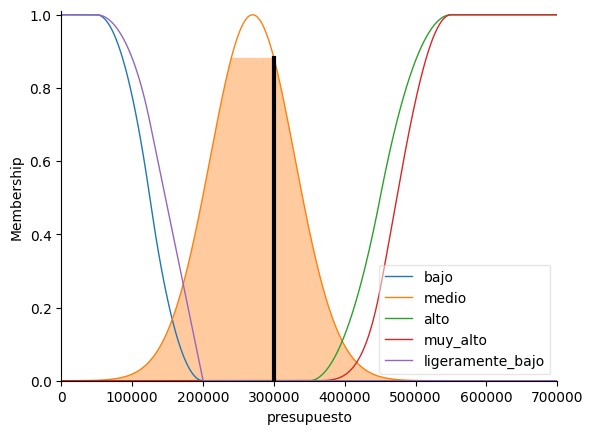

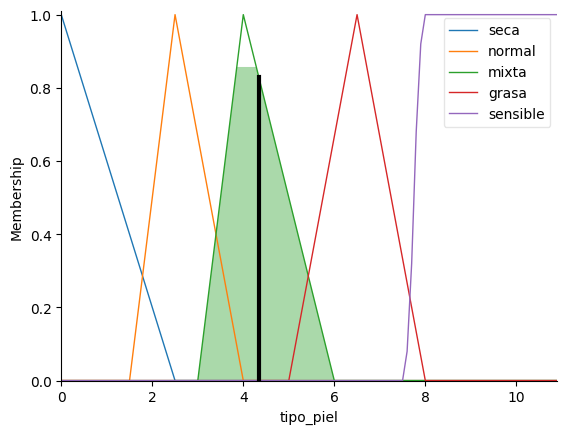

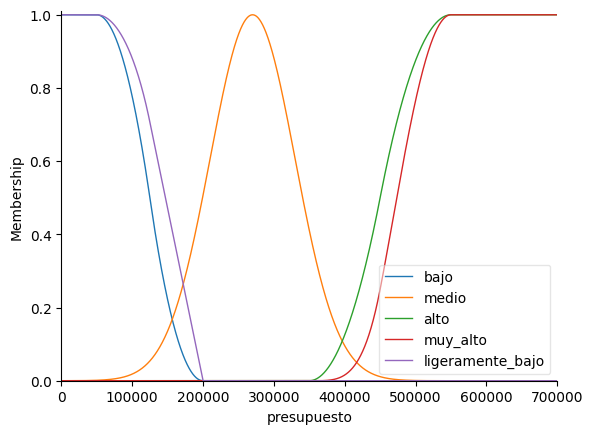

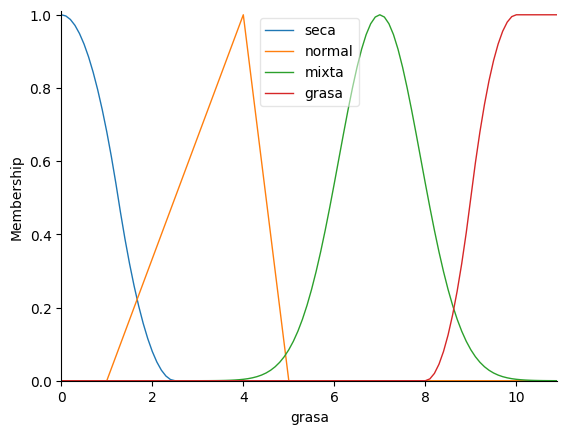

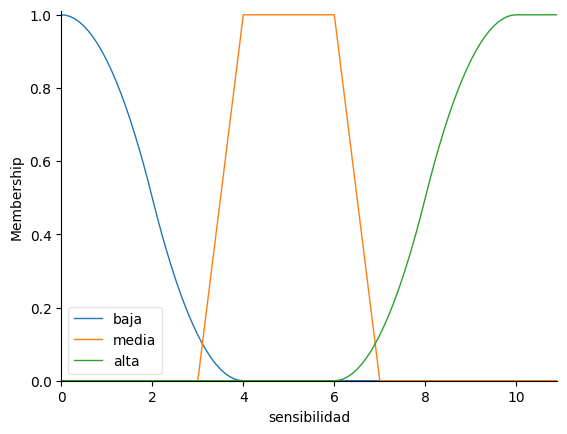

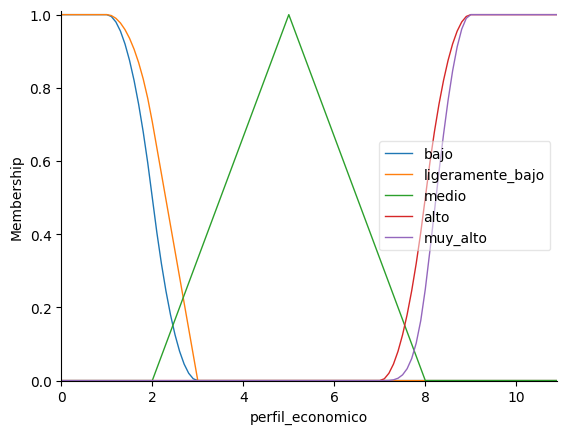

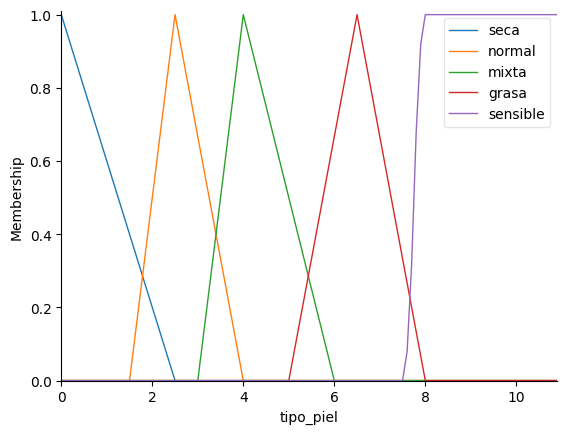

In [57]:
if __name__ == "__main__":
    # ============================================================
    # PERFILES DE USUARIOS PARA LÓGICA DIFUSA
    # Cada perfil incluye valores numéricos (para fuzzy) y datos
    # categóricos (para el sistema experto).
    # ============================================================

    perfiles_fuzzy = [
        {
            # Usuario A: presupuesto bajo, piel seca
            "nombre": "Usuario A",
            "presupuesto_val": 80_000,
            "nivel_grasa": 1.0,
            "nivel_sensibilidad": 1.5,
            # Datos categóricos para el sistema experto
            "marca_preferida": "NYX",
            "tipo_producto": "Maquillaje",
            "alergias": ["Colorantes"],
            "marcas_evitadas": ["Revlon"],
        },
        {
            # Usuario B: presupuesto medio, piel sensible
            "nombre": "Usuario B",
            "presupuesto_val": 150_000,
            "nivel_grasa": 3.0,
            "nivel_sensibilidad": 8.0,
            "marca_preferida": "Zara",
            "tipo_producto": "Prenda superior",
            "alergias": [],
            "marcas_evitadas": ["H&M"],
        },
        {
            # Usuario C: presupuesto medio-alto, piel grasa
            "nombre": "Usuario C",
            "presupuesto_val": 300_000,
            "nivel_grasa": 7.5,
            "nivel_sensibilidad": 2.0,
            "marca_preferida": "MAC",
            "tipo_producto": "Maquillaje",
            "alergias": [],
            "marcas_evitadas": ["NYX"],
            "visualizar_fuzzy": True,  # Opción para mostrar gráficos de fuzzy
        },
        {
            # Usuario D: presupuesto alto, piel mixta
            "nombre": "Usuario D",
            "presupuesto_val": 600_000,
            "nivel_grasa": 5.0,
            "nivel_sensibilidad": 4.0,
            "marca_preferida": "Fenty Beauty",
            "tipo_producto": "Maquillaje",
            "alergias": ["Fragancias"],
            "marcas_evitadas": [],
        },
    ]

    # ── Instanciar motor (se reutiliza para todos los usuarios) ──
    engine = SistemaRecomendacion()
    engine.strategy = DepthStrategy()  # LIFO
    engine.reset()
    hechos(engine)


    #contador de usuarios
    for perfil in perfiles_fuzzy:
        print("\n" + "=" * 80)
        print(f"PROCESANDO: usuario {perfil['nombre']}")
        print("=" * 80)

        # Paso 1 — Lógica difusa: valores numéricos → categorías
        perfil_econ, perfil_derm, sim_presupuesto, sim_piel = obtener_perfil_difuso(
            presupuesto_val=perfil["presupuesto_val"],
            nivel_grasa=perfil["nivel_grasa"],
            nivel_sensibilidad=perfil["nivel_sensibilidad"],
        )

        # Paso 2 — Sistema experto: usar las categorías obtenidas por fuzzy
        print("\n[SISTEMA EXPERTO] Ejecutando recomendaciones...")
        hecho_cliente = engine.declare(cliente(
            marca_preferida=perfil["marca_preferida"],
            tipo_producto=perfil["tipo_producto"],
            perfil_economico=perfil_econ,        # ← salida fuzzy
            perfil_dermatologico=perfil_derm,    # ← salida fuzzy
            alergias=perfil["alergias"],
            marcas_evitadas=perfil["marcas_evitadas"],
        ))
        engine.run()
        #mostrar gráficos de funciones de pertenencia si el perfil lo indica
        if visualizar_fuzzy := perfil.get("visualizar_fuzzy"):
            presupuesto.view(sim=sim_presupuesto)  # ← ControlSystemSimulation ✅
            tipo_piel.view(sim=sim_piel)           # ← ControlSystemSimulation ✅
            presupuesto.view()


            grasa.view()
            sensibilidad.view()
            perfil_economico.view()
            tipo_piel.view()


        engine.retract(hecho_cliente)

#test colab







# Grafico Turtle

In [58]:
ttl_data="""
@prefix cosm: <http://ia-recomendacion.co/ontologia#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

cosm:Cliente a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Cliente"@es ;
    rdfs:subClassOf cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Cliente ;
    owl:sameAs cosm:Cliente .

cosm:Entidad a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Entidad"@es ;
    rdfs:subClassOf cosm:Entidad,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Entidad ;
    owl:sameAs cosm:Entidad .

cosm:Ingrediente a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Ingrediente"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Ingrediente ;
    owl:sameAs cosm:Ingrediente .

cosm:Maquillaje a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Maquillaje"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Maquillaje ;
    owl:sameAs cosm:Maquillaje .

cosm:Marca a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Marca"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Marca ;
    owl:sameAs cosm:Marca .

cosm:PerfilCliente a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "PerfilCliente"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:PerfilCliente ;
    owl:sameAs cosm:PerfilCliente .

cosm:Persona a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Persona"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Persona ;
    owl:sameAs cosm:Persona .

cosm:Prenda a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Prenda"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Prenda,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Prenda ;
    owl:sameAs cosm:Prenda .

cosm:PrendaInferior a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "PrendaInferior"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaInferior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:PrendaInferior ;
    owl:sameAs cosm:PrendaInferior .

cosm:PrendaSuperior a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "PrendaSuperior"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:PrendaSuperior ;
    owl:sameAs cosm:PrendaSuperior .

cosm:Producto a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "Producto"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:Producto ;
    owl:sameAs cosm:Producto .

cosm:ProductoCosmetico a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:label "ProductoCosmetico"@es ;
    rdfs:subClassOf cosm:Entidad,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass cosm:ProductoCosmetico ;
    owl:sameAs cosm:ProductoCosmetico .

owl:Nothing a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:subClassOf cosm:Cliente,
        cosm:Entidad,
        cosm:Ingrediente,
        cosm:Maquillaje,
        cosm:Marca,
        cosm:PerfilCliente,
        cosm:Persona,
        cosm:Prenda,
        cosm:PrendaInferior,
        cosm:PrendaSuperior,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Nothing,
        owl:Thing ;
    owl:equivalentClass owl:Nothing ;
    owl:sameAs owl:Nothing .

owl:Thing a rdfs:Class,
        rdfs:Resource,
        owl:Class,
        owl:Thing ;
    rdfs:subClassOf rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass rdfs:Resource,
        owl:Thing ;
    owl:sameAs owl:Thing .

cosm:cli_UsuarioA a cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    cosm:tienePerfilEconomico cosm:perfil_UsuarioA ;
    cosm:tienePerfilPiel cosm:perfil_UsuarioA ;
    owl:sameAs cosm:cli_UsuarioA .

cosm:cli_UsuarioB a cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    cosm:tienePerfilEconomico cosm:perfil_UsuarioB ;
    cosm:tienePerfilPiel cosm:perfil_UsuarioB ;
    owl:sameAs cosm:cli_UsuarioB .

cosm:cli_UsuarioC a cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    cosm:tienePerfilEconomico cosm:perfil_UsuarioC ;
    cosm:tienePerfilPiel cosm:perfil_UsuarioC ;
    owl:sameAs cosm:cli_UsuarioC .

cosm:cli_UsuarioD a cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    cosm:tienePerfilEconomico cosm:perfil_UsuarioD ;
    cosm:tienePerfilPiel cosm:perfil_UsuarioD ;
    owl:sameAs cosm:cli_UsuarioD .

cosm:ing_Niquel a cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:label "Niquel"@es ;
    owl:sameAs cosm:ing_Niquel .

cosm:maq_Clinique_Hidratante a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_ExtractosVegetales ;
    cosm:esProducidoPor cosm:marca_Clinique ;
    owl:sameAs cosm:maq_Clinique_Hidratante .

cosm:maq_FentyBeauty_BaseMatificante a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_FentyBeauty ;
    owl:sameAs cosm:maq_FentyBeauty_BaseMatificante .

cosm:maq_Loreal_BaseLiquida a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_Loreal ;
    owl:sameAs cosm:maq_Loreal_BaseLiquida .

cosm:maq_Loreal_Labial a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_Loreal ;
    owl:sameAs cosm:maq_Loreal_Labial .

cosm:maq_Loreal_MascaraPestanas a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_Loreal ;
    owl:sameAs cosm:maq_Loreal_MascaraPestanas .

cosm:maq_MAC_BaseCobertura a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Aceites,
        cosm:ing_Colorantes,
        cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_MAC ;
    owl:sameAs cosm:maq_MAC_BaseCobertura .

cosm:maq_Maybelline_BaseLiquida a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_Maybelline ;
    owl:sameAs cosm:maq_Maybelline_BaseLiquida .

cosm:maq_Maybelline_Corrector a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_Maybelline ;
    owl:sameAs cosm:maq_Maybelline_Corrector .

cosm:maq_Maybelline_Delineador a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_Maybelline ;
    owl:sameAs cosm:maq_Maybelline_Delineador .

cosm:maq_NYX_Corrector a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_NYX ;
    owl:sameAs cosm:maq_NYX_Corrector .

cosm:maq_NYX_Labial a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_NYX ;
    owl:sameAs cosm:maq_NYX_Labial .

cosm:maq_Revlon_BaseLiquida a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes,
        cosm:ing_Fragancias ;
    cosm:esProducidoPor cosm:marca_Revlon ;
    owl:sameAs cosm:maq_Revlon_BaseLiquida .

cosm:maq_Revlon_PolvoCompacto a cosm:Entidad,
        cosm:Maquillaje,
        cosm:Producto,
        cosm:ProductoCosmetico,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_Revlon ;
    owl:sameAs cosm:maq_Revlon_PolvoCompacto .

cosm:marca_Levis a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Levis"^^xsd:string ;
    owl:sameAs cosm:marca_Levis .

cosm:marca_NARS a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "NARS"^^xsd:string ;
    owl:sameAs cosm:marca_NARS .

cosm:marca_Uniqlo a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Uniqlo"^^xsd:string ;
    owl:sameAs cosm:marca_Uniqlo .

cosm:sup_Bershka_TopCrop a cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_Bershka ;
    owl:sameAs cosm:sup_Bershka_TopCrop .

cosm:sup_HyM_CamisetaBasica a cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_HyM ;
    owl:sameAs cosm:sup_HyM_CamisetaBasica .

cosm:sup_PullAndBear_CamisetaGrafica a cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_PullAndBear ;
    owl:sameAs cosm:sup_PullAndBear_CamisetaGrafica .

cosm:sup_PullAndBear_SudaderaEstampada a cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    cosm:contieneIngrediente cosm:ing_Colorantes ;
    cosm:esProducidoPor cosm:marca_PullAndBear ;
    owl:sameAs cosm:sup_PullAndBear_SudaderaEstampada .

cosm:sup_Zara_CamisaOxford a cosm:Entidad,
        cosm:Prenda,
        cosm:PrendaSuperior,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    cosm:esProducidoPor cosm:marca_Zara ;
    owl:sameAs cosm:sup_Zara_CamisaOxford .

rdf:HTML a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs rdf:HTML .

rdf:PlainLiteral a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs rdf:PlainLiteral .

rdf:XMLLiteral a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs rdf:XMLLiteral .

rdf:langString a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs rdf:langString .

rdfs:comment a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs rdfs:comment .

rdfs:isDefinedBy a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs rdfs:isDefinedBy .

rdfs:seeAlso a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs rdfs:seeAlso .

xsd:NCName a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:NCName .

xsd:NMTOKEN a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:NMTOKEN .

xsd:Name a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:Name .

xsd:anyURI a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:anyURI .

xsd:base64Binary a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:base64Binary .

xsd:boolean a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:boolean .

xsd:byte a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:byte .

xsd:date a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:date .

xsd:dateTime a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:dateTime .

xsd:dateTimeStamp a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:dateTimeStamp .

xsd:decimal a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:decimal .

xsd:double a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:double .

xsd:float a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:float .

xsd:hexBinary a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:hexBinary .

xsd:int a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:int .

xsd:integer a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:integer .

xsd:language a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:language .

xsd:long a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:long .

xsd:negativeInteger a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:negativeInteger .

xsd:nonNegativeInteger a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:nonNegativeInteger .

xsd:nonPositiveInteger a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:nonPositiveInteger .

xsd:normalizedString a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:normalizedString .

xsd:positiveInteger a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:positiveInteger .

xsd:short a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:short .

xsd:time a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:time .

xsd:token a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:token .

xsd:unsignedByte a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:unsignedByte .

xsd:unsignedInt a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:unsignedInt .

xsd:unsignedLong a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:unsignedLong .

xsd:unsignedShort a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:unsignedShort .

owl:backwardCompatibleWith a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs owl:backwardCompatibleWith .

owl:deprecated a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs owl:deprecated .

owl:incompatibleWith a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs owl:incompatibleWith .

owl:priorVersion a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs owl:priorVersion .

owl:versionInfo a rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    owl:sameAs owl:versionInfo .

cosm:ing_Aceites a cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:label "Aceites"@es ;
    owl:sameAs cosm:ing_Aceites .

cosm:ing_ExtractosVegetales a cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:label "ExtractosVegetales"@es ;
    owl:sameAs cosm:ing_ExtractosVegetales .

cosm:marca_Bershka a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Bershka"^^xsd:string ;
    owl:sameAs cosm:marca_Bershka .

cosm:marca_Clinique a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Clinique"^^xsd:string ;
    owl:sameAs cosm:marca_Clinique .

cosm:marca_FentyBeauty a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "FentyBeauty"^^xsd:string ;
    owl:sameAs cosm:marca_FentyBeauty .

cosm:marca_HyM a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "HyM"^^xsd:string ;
    owl:sameAs cosm:marca_HyM .

cosm:marca_MAC a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "MAC"^^xsd:string ;
    owl:sameAs cosm:marca_MAC .

cosm:marca_Zara a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Zara"^^xsd:string ;
    owl:sameAs cosm:marca_Zara .

cosm:contieneIngrediente a rdf:Property,
        rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "contieneIngrediente"@es ;
    rdfs:domain cosm:Entidad,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:contieneIngrediente ;
    owl:equivalentProperty cosm:contieneIngrediente ;
    owl:sameAs cosm:contieneIngrediente .

cosm:esProducidoPor a rdf:Property,
        rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "esProducidoPor"@es ;
    rdfs:domain cosm:Entidad,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:esProducidoPor ;
    owl:equivalentProperty cosm:esProducidoPor ;
    owl:sameAs cosm:esProducidoPor .

cosm:evitaMarca a rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "evitaMarca"@es ;
    rdfs:domain cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:evitaMarca ;
    owl:equivalentProperty cosm:evitaMarca ;
    owl:sameAs cosm:evitaMarca .

cosm:marca_NYX a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "NYX"^^xsd:string ;
    owl:sameAs cosm:marca_NYX .

cosm:marca_PullAndBear a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "PullAndBear"^^xsd:string ;
    owl:sameAs cosm:marca_PullAndBear .

cosm:marca_Revlon a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Revlon"^^xsd:string ;
    owl:sameAs cosm:marca_Revlon .

cosm:nombreMarca a rdf:Property,
        rdfs:Resource,
        owl:DatatypeProperty,
        owl:Thing ;
    rdfs:label "nombreMarca"@es ;
    rdfs:domain cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range rdfs:Literal,
        xsd:string ;
    rdfs:subPropertyOf cosm:nombreMarca ;
    owl:equivalentProperty cosm:nombreMarca ;
    owl:sameAs cosm:nombreMarca .

cosm:perfilEconomicoValor a rdf:Property,
        rdfs:Resource,
        owl:DatatypeProperty,
        owl:Thing ;
    rdfs:label "perfilEconomicoValor"@es ;
    rdfs:domain cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range rdfs:Literal,
        xsd:string ;
    rdfs:subPropertyOf cosm:perfilEconomicoValor ;
    owl:equivalentProperty cosm:perfilEconomicoValor ;
    owl:sameAs cosm:perfilEconomicoValor .

cosm:perfil_UsuarioA a cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    cosm:perfilEconomicoValor "bajo"^^xsd:string ;
    cosm:tipoPiel "seca"^^xsd:string ;
    owl:sameAs cosm:perfil_UsuarioA .

cosm:perfil_UsuarioB a cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    cosm:perfilEconomicoValor "bajo"^^xsd:string ;
    cosm:tipoPiel "sensible"^^xsd:string ;
    owl:sameAs cosm:perfil_UsuarioB .

cosm:perfil_UsuarioC a cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    cosm:perfilEconomicoValor "medio"^^xsd:string ;
    cosm:tipoPiel "mixta"^^xsd:string ;
    owl:sameAs cosm:perfil_UsuarioC .

cosm:perfil_UsuarioD a cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    cosm:perfilEconomicoValor "bajo"^^xsd:string ;
    cosm:tipoPiel "mixta"^^xsd:string ;
    owl:sameAs cosm:perfil_UsuarioD .

cosm:prefiereMarca a rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "prefiereMarca"@es ;
    rdfs:domain cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:prefiereMarca ;
    owl:equivalentProperty cosm:prefiereMarca ;
    owl:sameAs cosm:prefiereMarca .

cosm:recomienda a rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "recomienda"@es ;
    rdfs:domain cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Producto,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:recomienda ;
    owl:equivalentProperty cosm:recomienda ;
    owl:sameAs cosm:recomienda .

cosm:tieneAlergia a rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "tieneAlergia"@es ;
    rdfs:domain cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:tieneAlergia ;
    owl:equivalentProperty cosm:tieneAlergia ;
    owl:sameAs cosm:tieneAlergia .

cosm:tienePerfilEconomico a rdf:Property,
        rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "tienePerfilEconomico"@es ;
    rdfs:domain cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:tienePerfilEconomico ;
    owl:equivalentProperty cosm:tienePerfilEconomico ;
    owl:sameAs cosm:tienePerfilEconomico .

cosm:tienePerfilPiel a rdf:Property,
        rdfs:Resource,
        owl:ObjectProperty,
        owl:Thing ;
    rdfs:label "tienePerfilPiel"@es ;
    rdfs:domain cosm:Cliente,
        cosm:Entidad,
        cosm:Persona,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:subPropertyOf cosm:tienePerfilPiel ;
    owl:equivalentProperty cosm:tienePerfilPiel ;
    owl:sameAs cosm:tienePerfilPiel .

cosm:tipoPiel a rdf:Property,
        rdfs:Resource,
        owl:DatatypeProperty,
        owl:Thing ;
    rdfs:label "tipoPiel"@es ;
    rdfs:domain cosm:Entidad,
        cosm:PerfilCliente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:range rdfs:Literal,
        xsd:string ;
    rdfs:subPropertyOf cosm:tipoPiel ;
    owl:equivalentProperty cosm:tipoPiel ;
    owl:sameAs cosm:tipoPiel .

rdf:type a rdf:Property ;
    rdfs:subPropertyOf rdf:type ;
    owl:equivalentProperty rdf:type ;
    owl:sameAs rdf:type .

rdfs:domain a rdf:Property ;
    rdfs:subPropertyOf rdfs:domain ;
    owl:equivalentProperty rdfs:domain ;
    owl:sameAs rdfs:domain .

rdfs:label a rdf:Property,
        rdfs:Resource,
        owl:AnnotationProperty,
        owl:Thing ;
    rdfs:subPropertyOf rdfs:label ;
    owl:equivalentProperty rdfs:label ;
    owl:sameAs rdfs:label .

rdfs:range a rdf:Property ;
    rdfs:subPropertyOf rdfs:range ;
    owl:equivalentProperty rdfs:range ;
    owl:sameAs rdfs:range .

rdfs:subClassOf a rdf:Property ;
    rdfs:subPropertyOf rdfs:subClassOf ;
    owl:equivalentProperty rdfs:subClassOf ;
    owl:sameAs rdfs:subClassOf .

rdfs:subPropertyOf a rdf:Property ;
    rdfs:subPropertyOf rdfs:subPropertyOf ;
    owl:equivalentProperty rdfs:subPropertyOf ;
    owl:sameAs rdfs:subPropertyOf .

owl:equivalentClass a rdf:Property ;
    rdfs:subPropertyOf owl:equivalentClass ;
    owl:equivalentProperty owl:equivalentClass ;
    owl:sameAs owl:equivalentClass .

owl:equivalentProperty a rdf:Property ;
    rdfs:subPropertyOf owl:equivalentProperty ;
    owl:equivalentProperty owl:equivalentProperty ;
    owl:sameAs owl:equivalentProperty .

owl:sameAs a rdf:Property ;
    rdfs:subPropertyOf owl:sameAs ;
    owl:equivalentProperty owl:sameAs ;
    owl:sameAs owl:sameAs .

cosm:marca_Loreal a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Loreal"^^xsd:string ;
    owl:sameAs cosm:marca_Loreal .

cosm:marca_Maybelline a cosm:Entidad,
        cosm:Marca,
        rdfs:Resource,
        owl:Thing ;
    cosm:nombreMarca "Maybelline"^^xsd:string ;
    owl:sameAs cosm:marca_Maybelline .

xsd:string a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:sameAs xsd:string .

owl:DatatypeProperty a rdfs:Resource,
        owl:Thing ;
    owl:sameAs owl:DatatypeProperty .

cosm:ing_Fragancias a cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:label "Fragancias"@es ;
    owl:sameAs cosm:ing_Fragancias .

owl:ObjectProperty a rdfs:Resource,
        owl:Thing ;
    owl:sameAs owl:ObjectProperty .

owl:AnnotationProperty a rdfs:Resource,
        owl:Thing ;
    owl:sameAs owl:AnnotationProperty .

cosm:ing_Colorantes a cosm:Entidad,
        cosm:Ingrediente,
        rdfs:Resource,
        owl:Thing ;
    rdfs:label "Colorantes"@es ;
    owl:sameAs cosm:ing_Colorantes .

rdf:Property owl:sameAs rdf:Property .

rdfs:Class a rdfs:Resource,
        owl:Thing ;
    rdfs:subClassOf rdfs:Class,
        owl:Class ;
    owl:equivalentClass rdfs:Class,
        owl:Class ;
    owl:sameAs rdfs:Class .

owl:Class a rdfs:Resource,
        owl:Thing ;
    rdfs:subClassOf rdfs:Class,
        owl:Class ;
    owl:equivalentClass rdfs:Class,
        owl:Class ;
    owl:sameAs owl:Class .

rdfs:Datatype a rdfs:Resource,
        owl:Thing ;
    rdfs:subClassOf rdfs:Datatype,
        owl:DataRange ;
    owl:equivalentClass rdfs:Datatype,
        owl:DataRange ;
    owl:sameAs rdfs:Datatype .

rdfs:Literal a rdfs:Datatype,
        rdfs:Resource,
        owl:DataRange,
        owl:Thing ;
    rdfs:subClassOf rdfs:Literal ;
    owl:equivalentClass rdfs:Literal ;
    owl:sameAs rdfs:Literal .

owl:DataRange a rdfs:Resource,
        owl:Thing ;
    rdfs:subClassOf rdfs:Datatype,
        owl:DataRange ;
    owl:equivalentClass rdfs:Datatype,
        owl:DataRange ;
    owl:sameAs owl:DataRange .

rdfs:Resource a rdfs:Resource,
        owl:Thing ;
    rdfs:subClassOf rdfs:Resource,
        owl:Thing ;
    owl:equivalentClass rdfs:Resource,
        owl:Thing ;
    owl:sameAs rdfs:Resource .

"""

# rdflib e inferencia OWLRL

In [59]:
!pip install rdflib owlrl

from rdflib import Graph
from owlrl import DeductiveClosure, RDFS_Semantics

# Crear grafo
g = Graph()

# Cargar RDF
g.parse(data=ttl_data, format="turtle")

originales=set(g)



print("\n\nANTES DE INFERIR")
for s, p, o in g:
    print(s, p, o)

# Aplicar inferencia RDFS 
DeductiveClosure(RDFS_Semantics).expand(g)

print("\n\n\n\nDESPUÉS DE INFERIR")
for s, p, o in g:
    print(s, p, o)
    
    

# Obtener solo inferidas
inferidas = set(g) - originales

print("\n\n\n\nTRIPLETAS INFERIDAS:\n")

for s, p, o in inferidas:
    print(s, p, o)



ANTES DE INFERIR
http://www.w3.org/2001/XMLSchema#unsignedByte http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://www.w3.org/2000/01/rdf-schema#Datatype
http://ia-recomendacion.co/ontologia#PerfilCliente http://www.w3.org/2000/01/rdf-schema#label PerfilCliente
http://ia-recomendacion.co/ontologia#cli_UsuarioA http://www.w3.org/2002/07/owl#sameAs http://ia-recomendacion.co/ontologia#cli_UsuarioA
http://www.w3.org/2001/XMLSchema#nonNegativeInteger http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://www.w3.org/2000/01/rdf-schema#Resource
http://ia-recomendacion.co/ontologia#perfil_UsuarioA http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://www.w3.org/2002/07/owl#Thing
http://www.w3.org/2001/XMLSchema#short http://www.w3.org/2002/07/owl#sameAs http://www.w3.org/2001/XMLSchema#short
http://ia-recomendacion.co/ontologia#Prenda http://www.w3.org/2002/07/owl#sameAs http://ia-recomendacion.co/ontologia#Prenda
http://ia-recomendacion.co/ontologia#esProducidoPor http://www.w3.org/200


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
